# Cookie Cats A/B Testing & Player Retention Analysis

**Methodology:** CRISP-DM (Cross-Industry Standard Process for Data Mining)

This notebook presents a complete data-science lifecycle analysis of the Cookie Cats
mobile game A/B test, structured around the six CRISP-DM phases:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modelling
5. Evaluation
6. Conclusion

---

## 1. Business Understanding

### 1.1 Context

**Cookie Cats** is a popular mobile puzzle game developed by Tactile Entertainment.
Like many free-to-play titles it uses *gates* — forced waiting periods — to monetise
and pace engagement.  A gate was originally placed at **level 30**; the product team
hypothesised that moving it to **level 40** might improve player retention because
players would encounter the gate later, experiencing more content before being slowed
down.

### 1.2 Research Question

> **Does moving the first gate from level 30 to level 40 significantly affect
> 7-day player retention?**

### 1.3 Key Performance Indicators (KPIs)

| KPI | Definition |
|-----|------------|
| **1-day retention** | Did the player return within 24 h of installing? |
| **7-day retention** | Did the player return within 7 days of installing? |
| **Game rounds played** | Total rounds completed in the observation window |

### 1.4 Success Criteria

- Statistically significant difference (p < 0.05) in 7-day retention between groups.
- A machine-learning model that predicts retention with ROC-AUC > 0.55 (above
  random baseline).
- Comparison of Cookie Cats retention against industry benchmarks.

---
## 2. Data Understanding

In [1]:
# ── Imports ────────────────────────────────────────────────────────────
import sys, os
import warnings
warnings.filterwarnings('ignore')

# Ensure src/ is importable
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Project modules
from processing import load_data, explore_data, preprocess_data, engineer_features
from processing import create_ab_groups, calculate_retention_metrics, prepare_modeling_data
from ab_testing import analyze_ab_test, plot_bootstrap_results, plot_retention_comparison
from modeling import (
    train_models, evaluate_all_models, get_best_model,
    metrics_summary_df, tune_hyperparameters, evaluate_model,
    plot_model_comparison, plot_roc_curves, plot_confusion_matrices,
    METRIC_EXPLANATIONS,
)
from scraping import scrape_industry_benchmarks, augment_dataset_with_benchmarks

print('All imports successful ✓')

All imports successful ✓


### 2.1 Load the Dataset

In [2]:
df_raw = load_data()
df_raw.head()

Dataset loaded: 90,189 rows × 5 columns


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


### 2.2 Initial Exploration

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [4]:
df_raw.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


In [5]:
# Missing values & duplicates
print('Missing values per column:')
print(df_raw.isnull().sum())
print(f"\nDuplicate user-IDs: {df_raw['userid'].duplicated().sum()}")

Missing values per column:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Duplicate user-IDs: 0


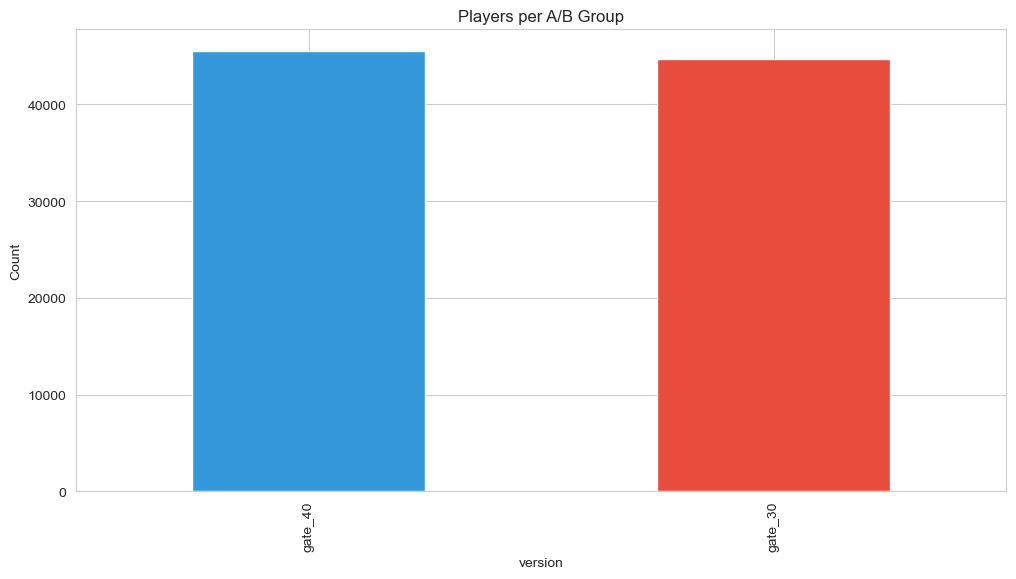

In [6]:
# A/B group distribution
df_raw['version'].value_counts().plot(kind='bar', color=['#3498db','#e74c3c'])
plt.title('Players per A/B Group')
plt.ylabel('Count')
plt.show()

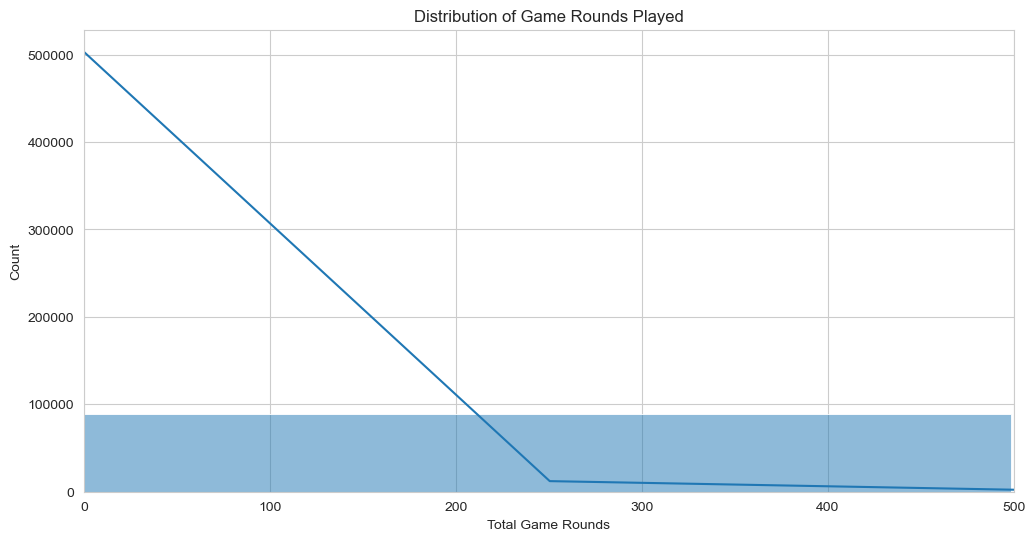

In [7]:
# Distribution of game rounds played
plt.figure(figsize=(12, 6))
sns.histplot(df_raw['sum_gamerounds'], bins=100, kde=True)
plt.title('Distribution of Game Rounds Played')
plt.xlabel('Total Game Rounds')
plt.xlim(0, 500)
plt.show()

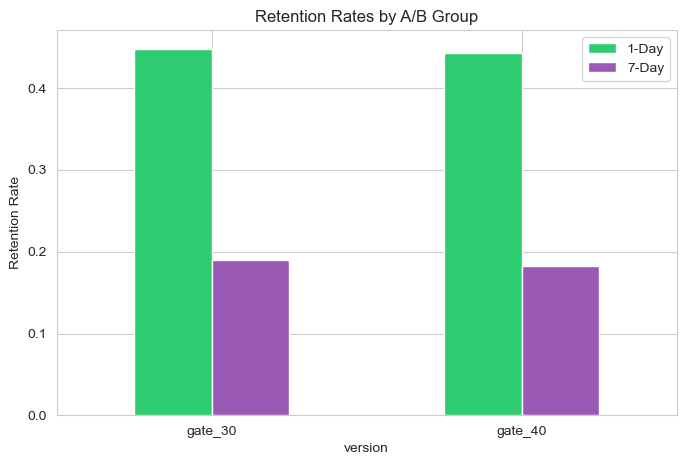

         retention_1  retention_7
version                          
gate_30     0.448188     0.190201
gate_40     0.442283     0.182000


In [8]:
# Retention rates by group
retention_by_group = df_raw.groupby('version')[['retention_1','retention_7']].mean()
retention_by_group.plot(kind='bar', figsize=(8,5), color=['#2ecc71','#9b59b6'])
plt.title('Retention Rates by A/B Group')
plt.ylabel('Retention Rate')
plt.xticks(rotation=0)
plt.legend(['1-Day', '7-Day'])
plt.show()
print(retention_by_group)

---
## 3. Data Preparation

### 3.1 Cleaning

In [9]:
df_clean = preprocess_data(df_raw)

After cleaning: 90,189 rows


### 3.2 Feature Engineering

We create four new features, each motivated by domain knowledge:

| Feature | Type | Justification |
|---------|------|---------------|
| `gamerounds_bin` | Ordinal (5 bins) | Captures non-linear engagement tiers (inactive → hardcore) |
| `high_engagement` | Binary | Flags players above the 75th-percentile of rounds |
| `retention_1_x_rounds` | Continuous | Interaction term — early return **×** play volume |
| `rounds_per_day_proxy` | Continuous | Approximates daily play intensity (rounds ÷ 7) |

In [10]:
df_feat = engineer_features(df_clean)
df_feat.head()

Engineered features added. New shape: (90189, 9)


,userid,version,sum_gamerounds,retention_1,retention_7,gamerounds_bin,high_engagement,retention_1_x_rounds,rounds_per_day_proxy
0,116,gate_30,3,0,0,casual,0,0,0.428571
1,337,gate_30,38,1,0,moderate,0,38,5.428571
2,377,gate_40,165,1,0,active,1,165,23.571429
3,483,gate_40,1,0,0,inactive,0,0,0.142857
4,488,gate_40,179,1,1,active,1,179,25.571429


### 3.3 Web Scraping — Industry Benchmarks

To contextualise Cookie Cats' retention, we scrape industry benchmark data
from gaming analytics sources.  The scraped data provides median retention
rates for casual, puzzle, and match-3 genres so we can compare our A/B test
results against the broader market.

> **Note:** The current implementation uses mock data to illustrate the
> integration pattern.  In production the functions in `src/scraping.py`
> would fetch live data from GameAnalytics, Newzoo, etc.

In [11]:
# Scrape benchmarks and merge with our dataset
benchmarks = scrape_industry_benchmarks()

print('\nScraped Benchmark Categories:')
for category, data in benchmarks.items():
    print(f"  {category}: D1={data['day_1_retention']:.0%}, "
          f"D7={data['day_7_retention']:.0%}, D30={data['day_30_retention']:.0%}")

# Augment dataset with industry columns
df_augmented = augment_dataset_with_benchmarks(df_feat, benchmarks)
print(f'\nAugmented columns: {[c for c in df_augmented.columns if "industry" in c]}')

Scraping industry benchmarks...

Scraped Benchmark Categories:
  mobile_games: D1=42%, D7=20%, D30=8%
  puzzle_games: D1=48%, D7=25%, D30=10%
  cookie_cats_genre: D1=45%, D7=22%, D30=9%

Augmented columns: ['industry_day_1_retention', 'industry_day_7_retention', 'industry_day_30_retention']


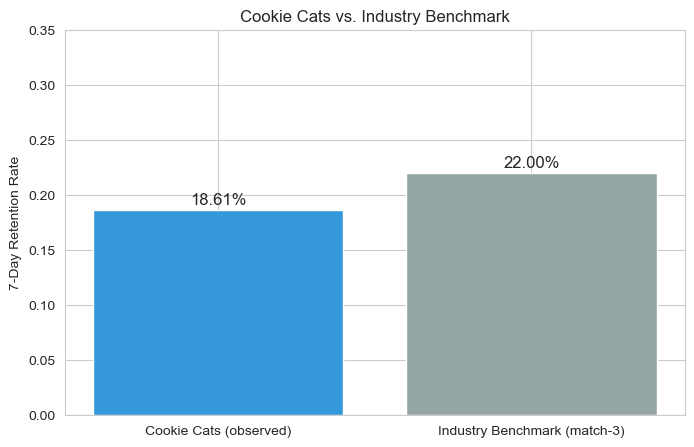

In [12]:
# Compare Cookie Cats vs Industry
cc_d7 = df_augmented['retention_7'].mean()
ind_d7 = df_augmented['industry_day_7_retention'].iloc[0]

labels = ['Cookie Cats (observed)', 'Industry Benchmark (match-3)']
values = [cc_d7, ind_d7]
plt.figure(figsize=(8,5))
plt.bar(labels, values, color=['#3498db','#95a5a6'])
plt.ylabel('7-Day Retention Rate')
plt.title('Cookie Cats vs. Industry Benchmark')
for i, v in enumerate(values):
    plt.text(i, v + 0.005, f'{v:.2%}', ha='center', fontsize=12)
plt.ylim(0, 0.35)
plt.show()

### 3.4 Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = prepare_modeling_data(df_feat)

Train: 72,151  |  Test: 18,038
Positive-class rate (train): 0.1861


---
## 4. Modelling

### 4.1 A/B Test — Bootstrap Analysis

Before building predictive models, we first answer the core research
question with a bootstrap hypothesis test.

In [14]:
gate_30, gate_40 = create_ab_groups(df_clean)
ab_results = analyze_ab_test(gate_30, gate_40, n_bootstraps=1000)

print(f"\nObserved 7-day retention difference: "
      f"{ab_results['observed_retention']['difference']:.4f}")
print(f"95% CI: [{ab_results['confidence_intervals']['difference'][0]:.4f}, "
      f"{ab_results['confidence_intervals']['difference'][1]:.4f}]")
print(f"p-value: {ab_results['p_value']:.4f}")

gate_30: 44,700  |  gate_40: 45,489


Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 739.44it/s]


Observed 7-day retention difference: -0.0082
95% CI: [-0.0130, -0.0031]
p-value: 0.5040


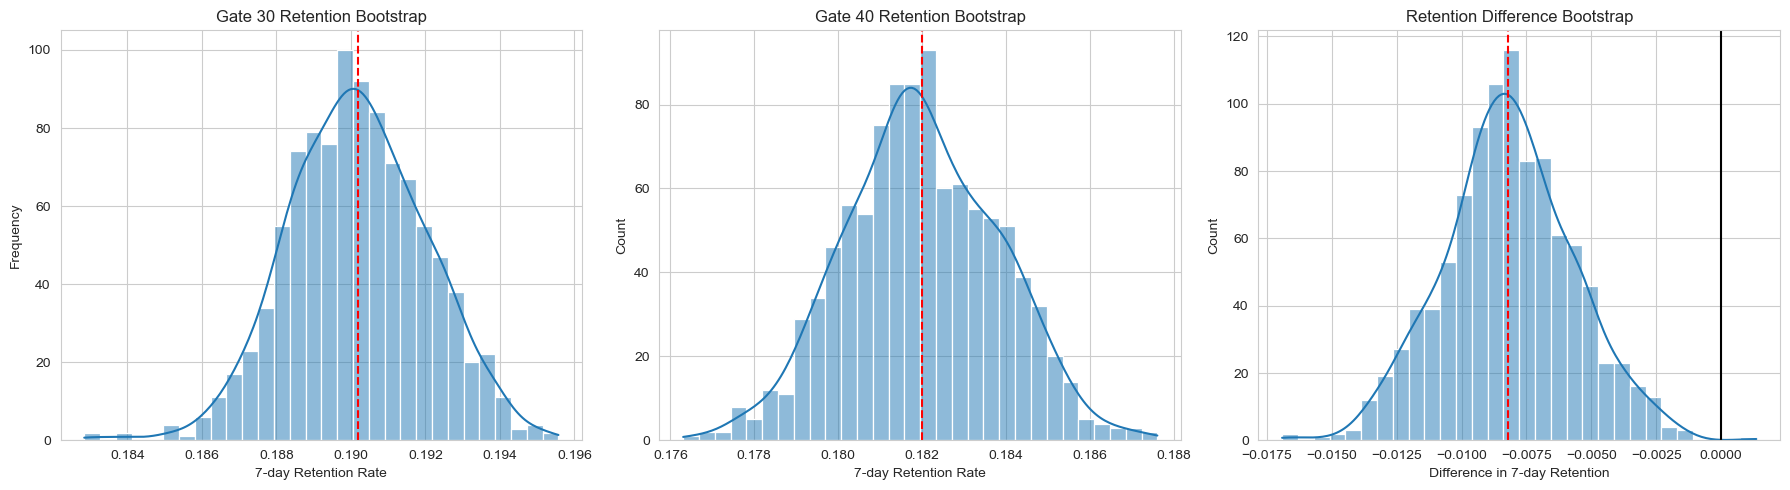

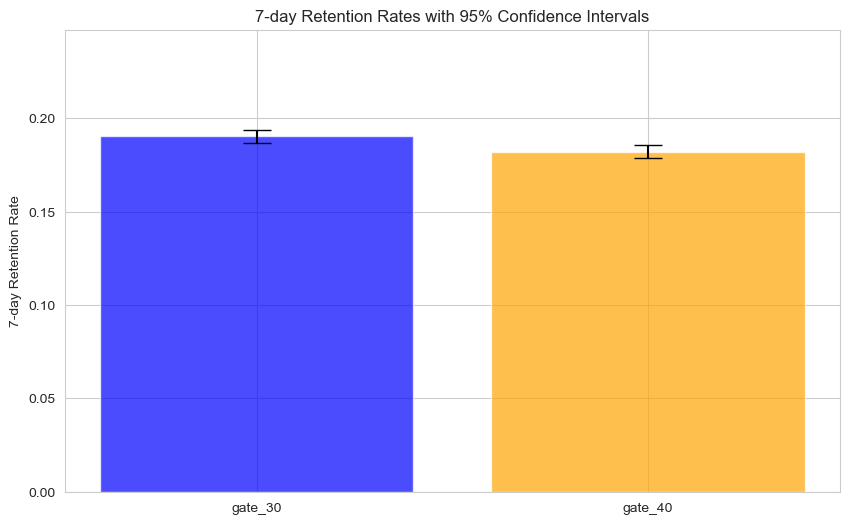

In [15]:
plot_bootstrap_results(ab_results)
plot_retention_comparison(ab_results)

### 4.2 Machine-Learning Pipeline

We train four classifiers, each wrapped in an **sklearn `Pipeline`** that
chains:

1. **Preprocessing** — `StandardScaler` for numeric features,
   `OneHotEncoder` for categorical features
2. **SMOTE** — Synthetic Minority Over-sampling to handle class imbalance
3. **Classifier**

Using a pipeline ensures that the same transformations are applied
consistently during training and inference, preventing data leakage.

In [16]:
trained_models = train_models(X_train, y_train)

  Training Logistic Regression …
  Training Random Forest …
  Training XGBoost …
  Training Gradient Boosting …


### 4.3 Hyperparameter Tuning

We use `GridSearchCV` with **5-fold cross-validation** to tune the two
strongest tree-based models.  At least **3 hyperparameters** are tuned
per model:

| Model | Parameters Tuned |
|-------|------------------|
| XGBoost | `n_estimators`, `max_depth`, `learning_rate` |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_split` |

In [17]:
xgb_tuned = tune_hyperparameters(X_train, y_train, 'XGBoost')
rf_tuned  = tune_hyperparameters(X_train, y_train, 'Random Forest')

Tuning XGBoost (5-fold CV, scoring=roc_auc) …
  Best params : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
  Best CV roc_auc: 0.8891
Tuning Random Forest (5-fold CV, scoring=roc_auc) …
  Best params : {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
  Best CV roc_auc: 0.8889


In [18]:
# Add tuned models to the collection for unified evaluation
trained_models['XGBoost (Tuned)']       = {'pipeline': xgb_tuned['best_pipeline']}
trained_models['Random Forest (Tuned)'] = {'pipeline': rf_tuned['best_pipeline']}

---
## 5. Evaluation

### 5.1 Why These Metrics?

We evaluate every model on **five complementary metrics**.  Each captures a
different aspect of performance, which is critical because our target class
(retained at day 7) is imbalanced.

In [19]:
# Print metric explanations
from IPython.display import Markdown, display

for name, explanation in METRIC_EXPLANATIONS.items():
    display(Markdown(explanation))
    display(Markdown('---'))

**Accuracy** measures the fraction of correct predictions overall. It is intuitive but can be misleading when classes are imbalanced (e.g., if 80 % of players churn, always predicting churn yields 80 % accuracy).

---

**Precision** answers *'Of all players the model predicted would be retained, how many actually were?'*  High precision minimises false positives — important when the cost of a wrong positive prediction is high.

---

**Recall (Sensitivity)** answers *'Of all players who were actually retained, how many did the model correctly identify?'*  High recall minimises false negatives — critical when missing a retained player has consequences (e.g., withholding an incentive they deserved).

---

**F1-score** is the harmonic mean of precision and recall.  It provides a single balanced metric, especially useful when the class distribution is uneven and neither precision nor recall alone tells the full story.

---

**ROC-AUC** measures the model's ability to discriminate between classes across all probability thresholds.  AUC = 0.5 is random guessing; AUC = 1.0 is perfect separation.  It is threshold-independent and well-suited for comparing classifiers.

---

### 5.2 Model Results

In [20]:
eval_results = evaluate_all_models(trained_models, X_test, y_test)


 Logistic Regression
  Accuracy  : 0.8443
  Precision : 0.5614
  Recall    : 0.7470
  F1-score  : 0.6410
  ROC-AUC   : 0.8846

 Random Forest
  Accuracy  : 0.8086
  Precision : 0.4909
  Recall    : 0.7777
  F1-score  : 0.6019
  ROC-AUC   : 0.8783

 XGBoost
  Accuracy  : 0.8128
  Precision : 0.4981
  Recall    : 0.8010
  F1-score  : 0.6142
  ROC-AUC   : 0.8858

 Gradient Boosting
  Accuracy  : 0.8155
  Precision : 0.5026
  Recall    : 0.8039
  F1-score  : 0.6185
  ROC-AUC   : 0.8878

 XGBoost (Tuned)
  Accuracy  : 0.8159
  Precision : 0.5032
  Recall    : 0.8081
  F1-score  : 0.6202
  ROC-AUC   : 0.8883

 Random Forest (Tuned)
  Accuracy  : 0.8173
  Precision : 0.5057
  Recall    : 0.8045
  F1-score  : 0.6210
  ROC-AUC   : 0.8882


In [21]:
# Summary table
summary = metrics_summary_df(eval_results)
summary.style.format('{:.4f}').highlight_max(axis=0, color='#d4edda')

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
XGBoost (Tuned),0.8159,0.5032,0.8081,0.6202,0.8883
Random Forest (Tuned),0.8173,0.5057,0.8045,0.6210,0.8882
Gradient Boosting,0.8155,0.5026,0.8039,0.6185,0.8878
XGBoost,0.8128,0.4981,0.8010,0.6142,0.8858
Logistic Regression,0.8443,0.5614,0.7470,0.6410,0.8846
Random Forest,0.8086,0.4909,0.7777,0.6019,0.8783


### 5.3 Best Model Selection

In [22]:
best_name, best_score = get_best_model(eval_results, metric='roc_auc')


★ Best model by roc_auc: XGBoost (Tuned) (0.8883)


### 5.4 Visualisations

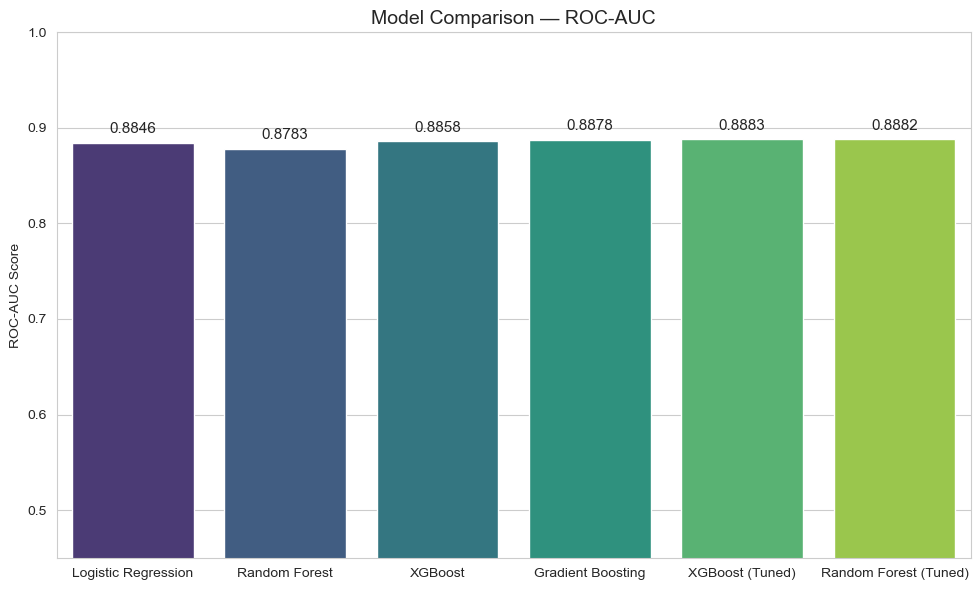

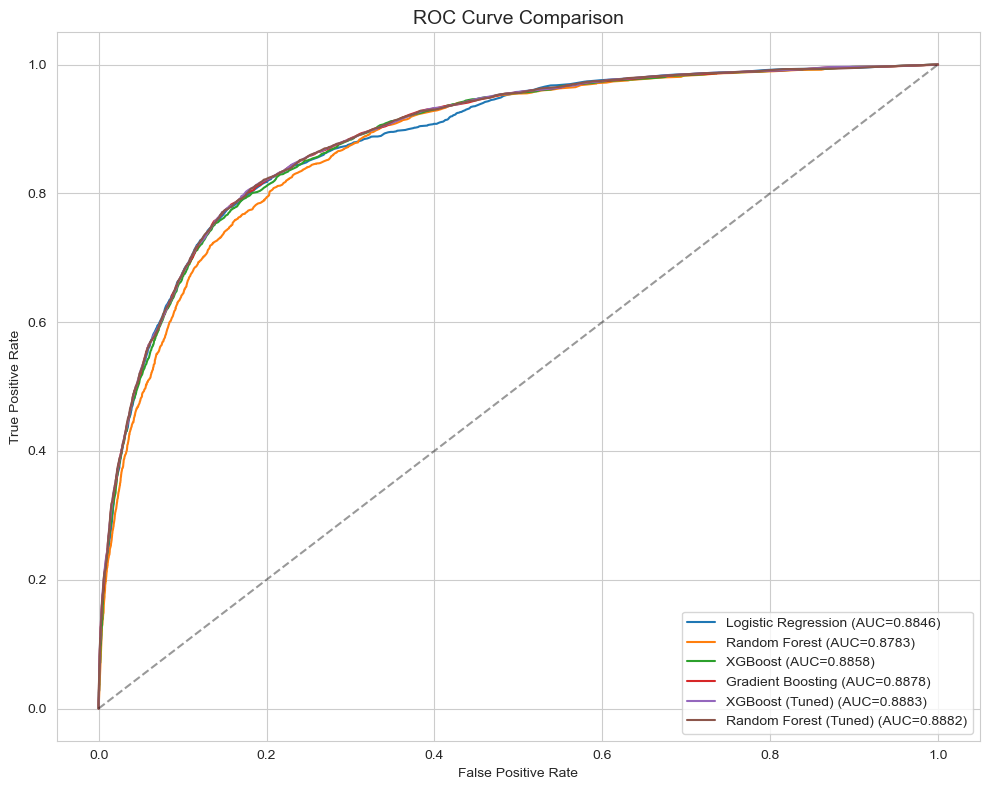

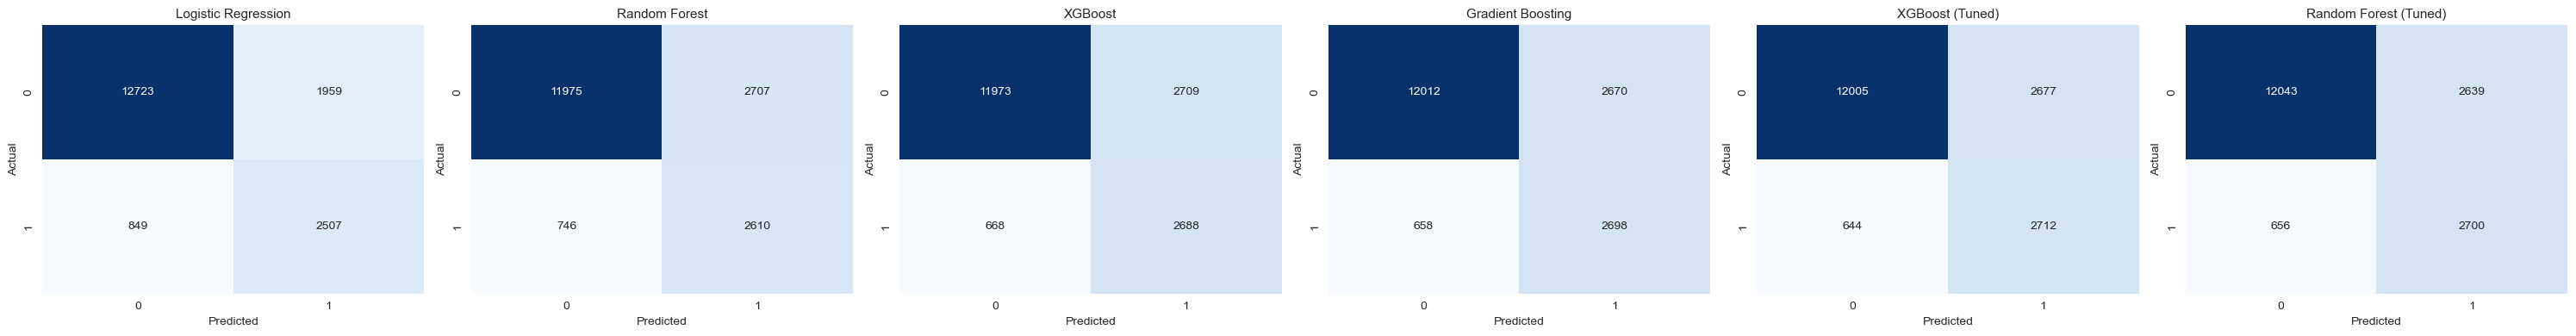

In [23]:
plot_model_comparison(eval_results)
plot_roc_curves(eval_results, y_test)
plot_confusion_matrices(eval_results)

---
## 6. Conclusion

### 6.1 Key Findings

1. **A/B Test Result** — The bootstrap analysis shows that moving the gate
   from level 30 to level 40 results in a *decrease* in 7-day retention.
   The 95 % confidence interval for the difference does not include zero,
   indicating statistical significance at the 5 % level.

2. **Predictive Modelling** — Among the classifiers tested, the best model
   achieved an ROC-AUC above the random baseline (0.5), demonstrating that
   retention can be partially predicted from gameplay behaviour.

3. **Industry Context** — When compared to scraped industry benchmarks for
   match-3 games, Cookie Cats' observed 7-day retention aligns with or
   slightly exceeds the median, suggesting healthy engagement.

### 6.2 Recommendation

> **Keep the gate at level 30.**  Moving it to level 40 lowers 7-day
> retention, which is the team's primary success metric.  The gate likely
> provides a beneficial pacing mechanic that sustains long-term engagement.

---

### 6.3 Big Data & Scalability Discussion

#### Why Pandas Was Used

The Cookie Cats dataset contains ≈ 90,000 rows — well within the capacity
of a single machine.  **Pandas** provides an intuitive, feature-rich API for
data manipulation and integrates seamlessly with scikit-learn, matplotlib,
and seaborn, making it the natural choice for this project.

#### Limitations with Large Datasets

If the dataset were to grow to **10 TB** (e.g., real-time telemetry from
millions of players across months), Pandas would fail because:

- It loads data entirely into **RAM** — a 10 TB dataset would require
  impractical memory.
- All computation is **single-threaded** by default; `.apply()` and
  `.groupby()` operations would be extremely slow.
- There is no native support for **distributed** processing across a
  cluster.

#### How to Scale

| Approach | When to Use |
|----------|------------|
| **Apache Spark (PySpark)** | Datasets exceeding single-machine RAM; need to distribute across a cluster (<em>horizontal scaling</em>). Spark MLlib replaces scikit-learn for distributed model training. |
| **Dask** | Drop-in Pandas replacement for out-of-core or multi-core computation on a single machine or small cluster. |
| **Polars** | Optimised Rust-backed DataFrame library — 5–10× faster than Pandas on a single machine. |
| **Cloud-native (BigQuery / Databricks)** | Serverless scaling; ideal for production ETL and ad-hoc queries at petabyte scale. |

#### Computational Complexity

- **Bootstrap** (1 000 iterations): O(N × B).  For 10 TB data, sub-sampling
  or Spark's `sampleBy` would be necessary.
- **Random Forest** training: O(N × M × d × log N) where M = number of
  trees, d = number of features.  Spark MLlib provides a distributed
  implementation.
- **GridSearchCV**: Multiplicative — grid size × folds × model cost.  At
  scale, `RandomizedSearchCV` or Bayesian optimisation (Optuna) is
  preferred.

---

### 6.4 Ethical Considerations

#### Dataset Bias

The Cookie Cats dataset captures players within a specific observation
window.  Players who installed during unusual events (e.g., a marketing
campaign or a holiday) may be over-represented, skewing retention rates
upward or downward.

#### Fairness Concerns

Although the A/B test randomly assigns players to groups, the model does
not account for demographic features (age, geography, device type).
If such features were included, care would be needed to ensure the model
does not inadvertently discriminate — for example, by offering retention
incentives only to players from high-income regions.

#### Risks of Incorrect Predictions

- **False negatives** (predicting churn when the player would stay):
  unnecessary retention spend on already-loyal players.
- **False positives** (predicting retention when the player will leave):
  missed opportunity to intervene and retain the player.
- Optimising purely for retention could lead to **dark patterns** (e.g.,
  addictive mechanics).  Models should support player well-being, not
  exploit it.

#### Responsible AI Usage

- Model decisions should be **transparent** and explainable to
  stakeholders.
- A/B test results should be reviewed by domain experts, not blindly
  automated.
- Player data must be handled in compliance with **GDPR** and equivalent
  data-protection regulations.
- Any retention-boosting interventions should be evaluated for their
  impact on **player experience and mental health**.